Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
Category
Technology         36.59
Furniture          32.22
Office Supplies    31.19
Name: Sales, dtype: float64
Sub-Category
Phones     327782.448
Chairs     322822.731
Storage    219343.392
Tables     202810.628
Binders    200028.785
Name: Sales, dtype: float64
Sub-Category
Phones     14.49
Chairs     14.27
Storage     9.70
Tables      8.97
Binders     8.84
Name: Sales, dtype: float64


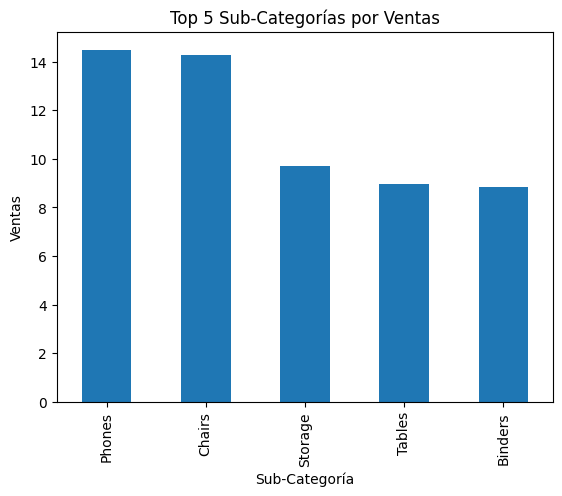

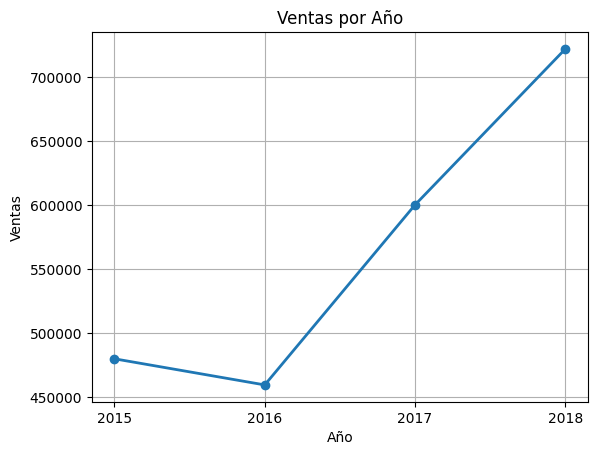

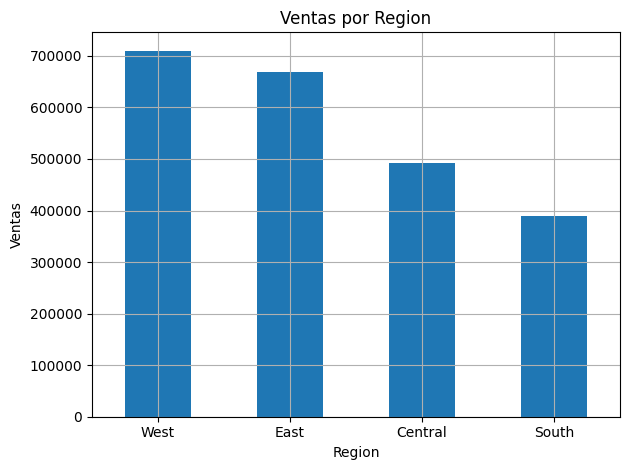

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\GEN5HDA\Downloads\train.csv")
df.head() #nos permite ver las primeras filas de dataset
ventas = df["Sales"].sum()
#df.columns #nos permite ver el nombre de las columnas del archivo

ventas_categoria = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print (ventas_categoria)
#Insight
#“La categoría Technology es el principal driver de ingresos, concentrando la mayor proporción de ventas dentro del negocio.”

ventas_categoria_porc = (df.groupby("Category")["Sales"].sum()/ ventas * 100).sort_values(ascending = False)
ventas_categoria_porc = (ventas_categoria_porc).round(2)
print(ventas_categoria_porc)
#Insight - “La categoría Technology lidera las ventas con un 36.59%, 
#sin embargo, las tres categorías presentan una distribución relativamente equilibrada, 
#lo que indica que el negocio no depende de una sola línea de productos.”

#df.columns
ventas_sub_categorias = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending = False)
print((ventas_sub_categorias.head(5)))
ventas_sub_categorias_porc = ((ventas_sub_categorias / ventas)) * 100
ventas_sub_categorias_porc = ventas_sub_categorias_porc.round(2)
print((ventas_sub_categorias_porc.head(5)))
#df.head(20) - me muestra los n filas del data set
#Insights
#“Aunque las subcategorías líderes muestran un alto volumen de ventas, 
#existe una diferencia moderada entre el primer y segundo lugar, 
#lo que sugiere una distribución relativamente equilibrada en la demanda de productos principales.”
#“Las ventas están moderadamente concentradas en las subcategorías Phones y Chairs, 
#que representan alrededor del 28.76% combinadas. Sin embargo, el resto de subcategorías mantiene una distribución relativamente balanceada, 
#lo que reduce el riesgo de dependencia excesiva en un solo producto.”

#Grafico de ventas por subcategoria
ventas_sub_categorias_porc.head(5).plot(kind = "bar")
plt.title("Top 5 Sub-Categorías por Ventas")
plt.xlabel("Sub-Categoría")
plt.ylabel("Ventas")
plt.show()
#Insight
#“Phones es la subcategoría con mayor contribución a las ventas, 
#lo que sugiere una alta dependencia del negocio en productos de tecnología de comunicación. 
#Esto posiciona a este segmento como un motor clave de ingresos dentro del portafolio de productos.”

#df.shape ----- #nos da el numero de filas y numero de columnas.

df[df.duplicated()]
df.drop_duplicates() #me ensena duplicados
df = df.drop_duplicates()
df.isnull().sum() #me ensena cuales son las columnas con datos nulos
df[df["Postal Code"].isnull()]
df["Postal Code"] = df["Postal Code"].fillna(5401) #con esto remplazamos los valores nulos con 5401 que es el postal code
df.isnull().sum()
df.head(5)

#Combertir ship date y order date a fechas reales 
#asi que estamos dejando que pandas detecte el formato.
df["Order Date"] = pd.to_datetime(df["Order Date"], format = "%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format = "%d/%m/%Y")
df["Order Date"].dt.year #- #aca me muestra solo los annos de la columna
df["Year"] = df["Order Date"].dt.year
sales_year = df.groupby("Year")["Sales"].sum()  #aca creamos la columna de ventas por anno
df.head(10)

#grafico de ventas por anno
sales_year.plot(kind = "line", marker = "o", linewidth=2) #Linewidth = 2 hace las lineas mas gruesas, y e; marker = o hace un circulo en el grafico por cada punto importante
plt.title("Ventas por Año")
plt.xlabel("Año")
plt.ylabel("Ventas")
plt.xticks(sales_year.index) #con esto veo el eje x de Años en numeros enteros ej:2015,2016 y no 2015, 2015.5
plt.grid() #le da cuadricula al grafico
plt.show()
#Insight
#“El análisis temporal revela que, desde 2016, las ventas han experimentado un crecimiento constante, sugiriendo una mejora en la demanda o en la estrategia comercial de la empresa.”

#Grafico ventas por region
ventas_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
ventas_region.plot(kind = "bar")
plt.title("Ventas por Region")
plt.xlabel("Region")
plt.ylabel("Ventas")
plt.xticks(rotation=0)  #esto ayuda a que las letras del eje x esten horizontal y no inclinadas
plt.grid()
plt.tight_layout()
plt.show()
#Insight
# “La región con mayor volumen de ventas es WEST, lo que indica una mayor concentración de ingresos en esta zona geográfica. Esto sugiere oportunidades para replicar estrategias en regiones de menor desempeño.”
# =========================
# CONCLUSION FINAL
# =========================
# El análisis muestra que la categoría Technology lidera las ventas,
# aunque el negocio mantiene una distribución equilibrada entre categorías.
# A nivel de subcategorías, Phones y Chairs son los principales impulsores de ingresos.
# Además, se observa un crecimiento sostenido en ventas desde 2016,
# lo que sugiere una expansión positiva del negocio en el tiempo.